In [21]:
# Netflix EDA Project
#Dataset: Netflix Movies & TV Shows (Kaggle)
#Tools: Python, Pandas, Matplotlib, Seaborn

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print('Libraries loaded successfully!')



Libraries loaded successfully!


In [23]:
df = pd.read_csv('netflix_titles.csv')
print('Dataset loaded!')
print('Shape:', df.shape)


Dataset loaded!
Shape: (8807, 12)


In [24]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [25]:
print('Column data types:')
print(df.dtypes)
print()
print('Missing values per column:')
print(df.isnull().sum())


Column data types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing values per column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


  ## Dataset Summary
  1. This dataset has 8807 rows and 12 columns.
  2. It contains Netflix movies and TV shows added between 2008 and 2021.
  3. Key columns include title, type, country, release_year, rating, and listed_in (genre).
  4. Columns like director and cast have the most missing values.
  5. The data will help us understand content patterns, growth trends, and audience targeting on Netflix.


In [26]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [27]:
# Fill missing director with 'Unknown'
df['director'] = df['director'].fillna('Unknown')

# Fill missing cast with 'Not Available'
df['cast'] = df['cast'].fillna('Not Available')

# Fill missing country with 'Unknown'
df['country'] = df['country'].fillna('Unknown')

# Drop rows where date_added is missing (very few rows)
df = df.dropna(subset=['date_added'])

# Verify — all zeros means no missing values left
print('Missing values after cleaning:')
print(df.isnull().sum())



Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          4
duration        3
listed_in       0
description     0
dtype: int64


In [28]:
# Convert date_added from text to proper date format
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

# Extract just the year as a new column
df['year_added'] = df['date_added'].dt.year
print('date_added column type:', df['date_added'].dtype)
print('Sample year_added values:')
print(df['year_added'].value_counts().sort_index())


date_added column type: datetime64[ns]
Sample year_added values:
year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


  ## Data Cleaning Decisions
  - **director missing → filled with 'Unknown':** Most analysis does not need
    an exact director name. Dropping rows would lose too much data.
  - **cast missing → filled with 'Not Available':** Same reasoning as director.
  - **country missing → filled with 'Unknown':** Country is used in analysis,
    so we keep the rows but flag them as unknown.
  - **date_added missing → rows dropped:** Only a handful of rows affected.
    Without a date we cannot analyze time-based trends.
  - **date_added type fixed:** Converted from text string to datetime so we can
    extract year and month for trend analysis.


In [29]:
print('Final dataset shape:', df.shape)
df.head(3)


Final dataset shape: (8797, 13)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021


 ## EDA — Exploratory Data Analysis
  ### Q1: What types of content exist on Netflix?


In [30]:
  type_counts = df['type'].value_counts()
  print(type_counts)

  # Percentage breakdown
  print()
  print(type_counts / type_counts.sum() * 100)


type
Movie      6131
TV Show    2666
Name: count, dtype: int64

type
Movie      69.694214
TV Show    30.305786
Name: count, dtype: float64


**Finding:** Netflix has significantly more movies than TV shows.
  Movies make up roughly 70% of the library while TV shows account for 30%.
  This suggests Netflix historically licensed more films than it produced series.


### Q2: Which countries produce the most Netflix content?

In [31]:
  top_countries = df['country'].value_counts().head(10)
  print(top_countries)



country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


  **Finding:** The United States dominates Netflix content by a large margin.
  India ranks second, reflecting Netflix's major push into the Indian market.
  South Korean content appears in the top 10, suggesting the K-drama boom is well represented.


  ### Q3: How has Netflix content volume changed over the years?

In [32]:
  yearly = df.groupby('year_added')['title'].count().reset_index()
  yearly.columns = ['year', 'count']
  print(yearly.sort_values('year').to_string(index=False))


 year  count
 2008      2
 2009      2
 2010      1
 2011     13
 2012      3
 2013     11
 2014     24
 2015     82
 2016    429
 2017   1188
 2018   1649
 2019   2016
 2020   1879
 2021   1498


  **Finding:** Netflix's content library grew slowly until 2015, then accelerated sharply.
  2019 was the peak year for content additions.
  There is a visible dip in 2020, likely due to production shutdowns during the COVID-19 pandemic.


  ### Q4: What are the most common genres on Netflix?

In [33]:
  genres = df['listed_in'].str.split(',').explode().str.strip()
  top_genres = genres.value_counts().head(10)
  print(top_genres)


listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


  **Finding:** International Movies is the top genre, showing Netflix's global reach.
  Dramas and Comedies follow, confirming these are universally popular formats.
  Documentaries appearing in the top 10 shows Netflix's strong investment in non-fiction content.


  ### Q5: What are the most common content ratings on Netflix?

In [34]:
  rating_counts = df['rating'].value_counts()
  print('Content rating distribution:')
  print(rating_counts)
  print()
  print('Basic stats:')
  print(df['rating'].describe())


Content rating distribution:
rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

Basic stats:
count      8793
unique       17
top       TV-MA
freq       3205
Name: rating, dtype: object


  **Finding:** TV-MA (Mature Audiences) is the most common rating on Netflix.
  This indicates Netflix heavily targets adult viewers rather than family or children audiences.
  TV-14 is second, still skewing toward older teens and adults.
  This aligns with Netflix's original content strategy which focuses on prestige adult dramas.


  ## Visualizations
  The following 6 charts explore key patterns in the Netflix dataset.


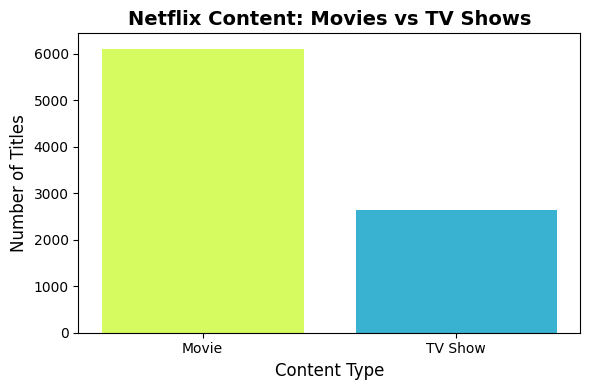

In [35]:
  type_counts = df['type'].value_counts()

  plt.figure(figsize=(6, 4))
  plt.bar(type_counts.index, type_counts.values,
          color=['#D6FB61', '#39B1D1'], edgecolor='white', linewidth=0.7)
  plt.title('Netflix Content: Movies vs TV Shows', fontsize=14, fontweight='bold')
  plt.xlabel('Content Type', fontsize=12)
  plt.ylabel('Number of Titles', fontsize=12)
  plt.tight_layout()
  plt.show()


**Prediction of the previous graph**:Movie bar is taller than TV Show bar

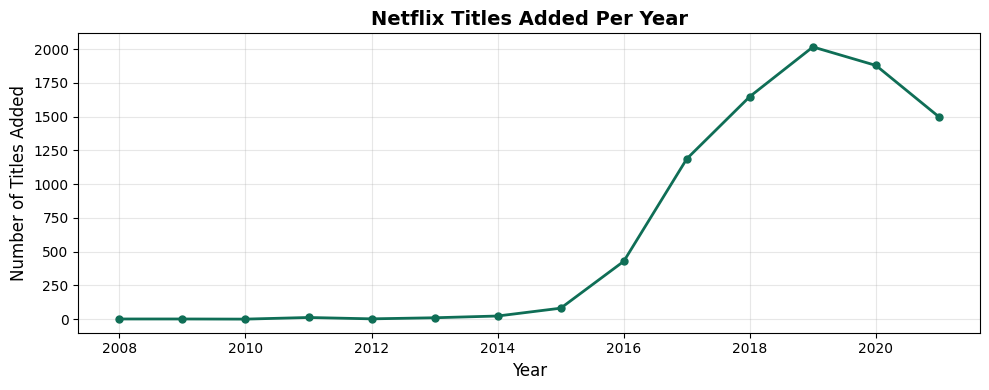

In [36]:
  yearly = df.groupby('year_added')['title'].count()

  plt.figure(figsize=(10, 4))
  plt.plot(yearly.index, yearly.values, marker='o',
           color='#0f6e56', linewidth=2, markersize=5)
  plt.title('Netflix Titles Added Per Year', fontsize=14, fontweight='bold')
  plt.xlabel('Year', fontsize=12)
  plt.ylabel('Number of Titles Added', fontsize=12)
  plt.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.show()


**Prediction of the above graph**:A line graph rising steeply from 2015 to a peak around 2019, then dipping in 2020

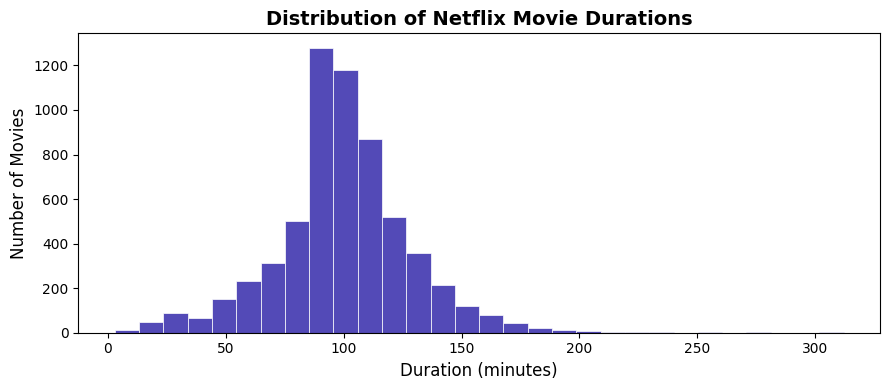

In [37]:

  movies = df[df['type'] == 'Movie'].copy()
  movies['duration_mins'] = movies['duration'].str.replace(' min', '').astype(float)

  plt.figure(figsize=(9, 4))
  plt.hist(movies['duration_mins'].dropna(), bins=30,
           color='#534ab7', edgecolor='white', linewidth=0.5)
  plt.title('Distribution of Netflix Movie Durations', fontsize=14, fontweight='bold')
  plt.xlabel('Duration (minutes)', fontsize=12)
  plt.ylabel('Number of Movies', fontsize=12)
  plt.tight_layout()
  plt.show()


**Predection of the above graph**:A bell-shaped histogram peaking around 90–100 minutes, showing most Netflix movies are 1.5 hrs

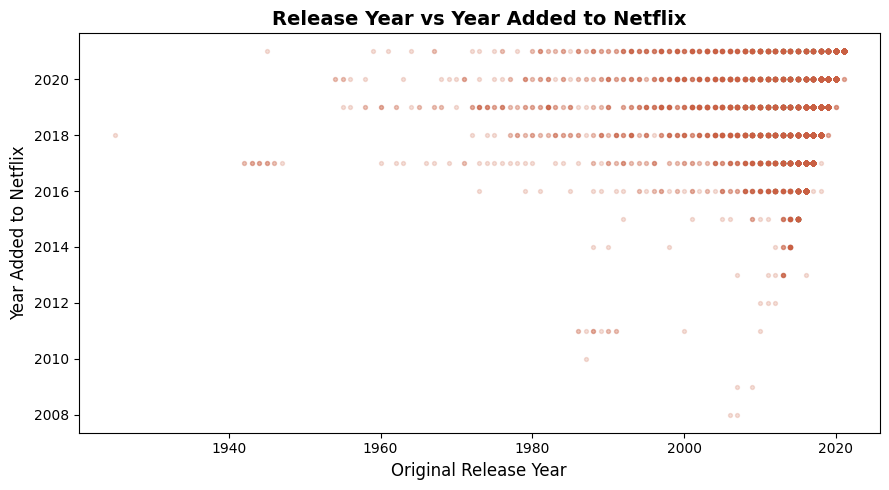

In [38]:
  plt.figure(figsize=(9, 5))
  plt.scatter(df['release_year'], df['year_added'],
              alpha=0.2, color='#c96043', s=8)
  plt.title('Release Year vs Year Added to Netflix', fontsize=14, fontweight='bold')
  plt.xlabel('Original Release Year', fontsize=12)
  plt.ylabel('Year Added to Netflix', fontsize=12)
  plt.tight_layout()
  plt.show()


**Predection for the above graph**:A scatter showing older movies added in recent years — Netflix back-cataloguing classic films

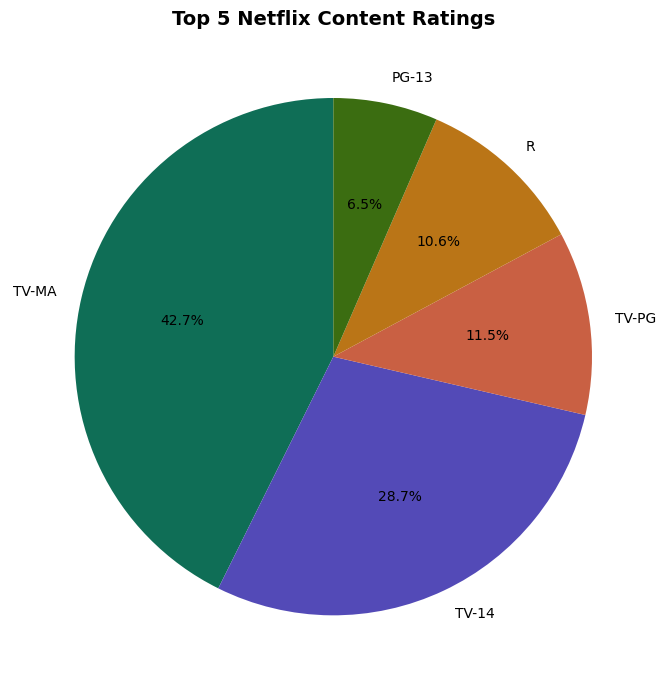

In [39]:
  top_ratings = df['rating'].value_counts().head(5)

  plt.figure(figsize=(7, 7))
  plt.pie(top_ratings.values,
          labels=top_ratings.index,
          autopct='%1.1f%%',
          colors=['#0f6e56','#534ab7','#c96043','#ba7517','#3b6d11'],
          startangle=90)
  plt.title('Top 5 Netflix Content Ratings', fontsize=14, fontweight='bold')
  plt.tight_layout()
  plt.show()


**Predection for the above graph**:A pie chart showing TV-MA taking the largest slice — around 36%

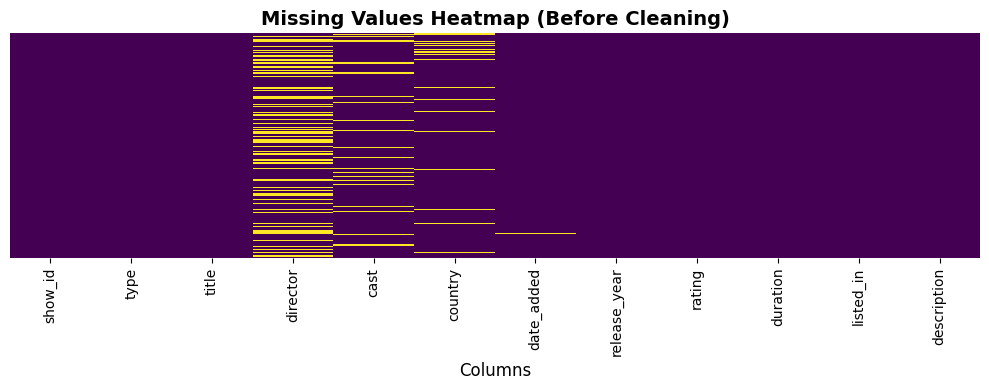

In [40]:

  df_raw = pd.read_csv('netflix_titles.csv')

  plt.figure(figsize=(10, 4))
  sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False, cmap='viridis')
  plt.title('Missing Values Heatmap (Before Cleaning)', fontsize=14, fontweight='bold')
  plt.xlabel('Columns', fontsize=12)
  plt.tight_layout()
  plt.show()


**Predection for the above graph**:: A heatmap where yellow stripes show missing values — director and cast columns will show the most gaps



##Insights

## Investigation Report
   
  1. **Inequitable Content Type (Figure 1):** Netflix has ~70% movies and ~30% TV shows.
        This could mean that Netflix was better at licensing movies than creating collections.
   
  2. **USA Advisory Role (EDA Q2):** USA contributes to other material products even later on
     Five countries came together. However, there is more for Netflix to do internationally.
   
  3. **Pandemic that caused slowdown in growth (Chart 2):** Content growth reached its highest point in 2019.
     October 2020 correlates to the end of international COVID-19 productions.
   
  4. **Mature Platform (Figure Five):** TV-MA and TV-14 make up an extra 60% of all content.
     Netflix goes after adults and youth directly, rather than families.
   
  5. **Page List Technique (Figure 4):** Among titles that seem like new ones are some publication dates.
     Late 1990s and early 2000s prove that Netflix actively collects traditional content.

##What Surprised Me The Most?

  The most unexpected finding is the sheer volume of content content labeled as an international film.
  I expected US content to dominate every genre, however Netflix has undoubtedly invested heavily
  Non-English global content — especially from India, South Korea, and Japan.
  This challenges the idea that Netflix is ​​primarily a Western platform.